# This notebook demonstrates the use of Multi-region Sparse Component Analysis (mSCA) using a cycling dataset

* Data are trial-averaged firing rates of individual neurons collected from motor cortex (primary motor and dorsal premotor) of a non-human primate.

* The monkey was performing a cycling task ([Russo et al., 2018](https://pubmed.ncbi.nlm.nih.gov/29398358/))

* Briefly, this task involves the monkey using a bicycle pedal to traverse a virtual environment.

* On each trial, the monkey is told how many cycles he will have to perform (0.5, 1,2,4, or 7).

* After a variable delay period, the monkey receives a go cue, and he pedals to the target, comes to a stop, and is given a juice reward.

* Single-trial rates have been (lightly) stretched or compressed such that each individual cycle is the same duration.

In [5]:
import matplotlib.pyplot as plt
from msca import *
import os
import importlib
import msca
import msca.models
import msca.architectures
import msca.utils
import msca.simulations
# Suppress MallocStackLogging warnings on macOS
os.environ["MallocStackLogging"] = "0"

# Reload msca and key submodules after code changes
importlib.reload(msca.architectures)
importlib.reload(msca.models)
importlib.reload(msca.utils)
importlib.reload(msca)
importlib.reload(msca.simulations)


# Re-import updated symbols
from msca import *




## Load data
monkey Cousteau

In [6]:
import scipy.io as sio

mat = sio.loadmat("./data/Cousteau_interp_cycling_m1_rawRates.mat")
mask = mat["mask"]

print(mask.dtype.names)  
for k in mask.dtype.names:
    v = mask[k][0, 0]
    print(k, type(v), getattr(v, "shape", None))

('time', 'dist', 'dir', 'pos', 'cycleNum', 'condNum', 'worldPos', 'firstTimeEachCond', 'lastTimeEachCond', 'timeIndices', 'cellIDs', 'cellNames')
time <class 'numpy.ndarray'> (1, 70228)
dist <class 'numpy.ndarray'> (70228, 1)
dir <class 'numpy.ndarray'> (70228, 1)
pos <class 'numpy.ndarray'> (70228, 1)
cycleNum <class 'numpy.ndarray'> (70228, 1)
condNum <class 'numpy.ndarray'> (70228, 1)
worldPos <class 'numpy.ndarray'> (0, 0)
firstTimeEachCond <class 'numpy.ndarray'> (1, 20)
lastTimeEachCond <class 'numpy.ndarray'> (1, 20)
timeIndices <class 'numpy.ndarray'> (0, 0)
cellIDs <class 'numpy.ndarray'> (1, 4)
cellNames <class 'scipy.io.matlab._mio5_params.MatlabOpaque'> (1,)


In [7]:
import importlib
import os
import numpy as np
from scipy import io


def load_data(dir_path, f):
    # Load in matlab file
    mat_file = io.loadmat(dir_path + f)

    # Grab data and mask
    data_array = mat_file["data"]
    mask = mat_file["mask"]

    # Grab the start and end indices for each trial
    start_idxs = mat_file["mask"]["firstTimeEachCond"][0][0].squeeze() - 1
    end_idxs = mat_file["mask"]["lastTimeEachCond"][0][0].squeeze()

    return data_array, mask, start_idxs, end_idxs


# Preprocess the loaded data and split into trials
def preprocess(data_array, start_idxs, end_idxs, downsample_factor=5):
    """
    Pre-processing done by Andrew Zimnik
    """
    # Downsample the data
    if downsample_factor is not None:
        data_downsamp = data_array[::downsample_factor]

        # Adjust the start and end indices to account for the downsampling
        start_idxs = start_idxs // downsample_factor
        end_idxs = end_idxs // downsample_factor
    else:
        data_downsamp = data_array

    # Transpose the data to N x TC
    data_concat = data_downsamp.T

    # fr range (for normalizing later)
    fr_range = np.ptp(data_concat, axis=1)[:, None]

    # Soft normalize (divide each neuron by its range + 5)
    data_norm = data_concat / (fr_range + 5)

    # mean-center each neuron
    data_snm_norm = data_norm - np.mean(data_norm, axis=1)[:, None]

    # rename the data for convenience
    # Note that model requires (T x N) input rather than (N x T), which is why there are transposes below
    fit_data = np.copy(data_snm_norm.T)

    # Split the data into trials
    split_data = [fit_data[i:j] for i, j in zip(start_idxs, end_idxs)]

    return split_data




fp = "./data/"
m1_data, m1_mask, m1_start_idxs, m1_end_idxs = load_data(
    f"{fp}", "Cousteau_interp_cycling_m1_rawRates.mat"
)
sma_data, sma_mask, sma_start_idxs, sma_end_idxs = load_data(
    f"{fp}", "Cousteau_interp_cycling_sma_rawRates.mat"
)

# Preprocess the data
m1_preprocessed = preprocess(
    m1_data, m1_start_idxs, m1_end_idxs, downsample_factor=5
)
sma_preprocessed = preprocess(
    sma_data, sma_start_idxs, sma_end_idxs, downsample_factor=5
)

# Put data into dictionary format
X = {"M1": m1_preprocessed, "SMA": sma_preprocessed}


In [8]:
import numpy as np

# full dir time series
dir_all = m1_mask["dir"][0, 0].squeeze()

# trial 0 window
tid = 0
s = int(m1_start_idxs[tid])
e = int(m1_end_idxs[tid])
d = dir_all[s:e]

print("trial", tid, "dir values (first 20):", d[:20])
print("unique values:", np.unique(d))
print("majority dir:", np.unique(d, return_counts=True)[0][np.argmax(np.unique(d, return_counts=True)[1])])

trial 0 dir values (first 20): [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
unique values: [1]
majority dir: 1


## Trained model using nonlinear encoder and nonlinear decoder
n_components=40


In [9]:
# instantiate and fit mSCA model
# defualt lam_orthog is 0.1
msca = mSCA(n_components=30, n_epochs=2500, loss_func="Gaussian", lr=1e-3, filter_len=41, linear=False, region_weights=None, lam_sparse=2.5,lam_orthog=0.1, lam_region=None, batch_size=64, cd_rate=0.5, decoder_type="triple_layer",post_hoc_epoch=-1)
# load model parameters 
msca.load("./results/Cousteau/msca_TripleLayerDecoder.pt", X)


## Show Latents learned from the nonlinear encoder and nonlinear decoder model

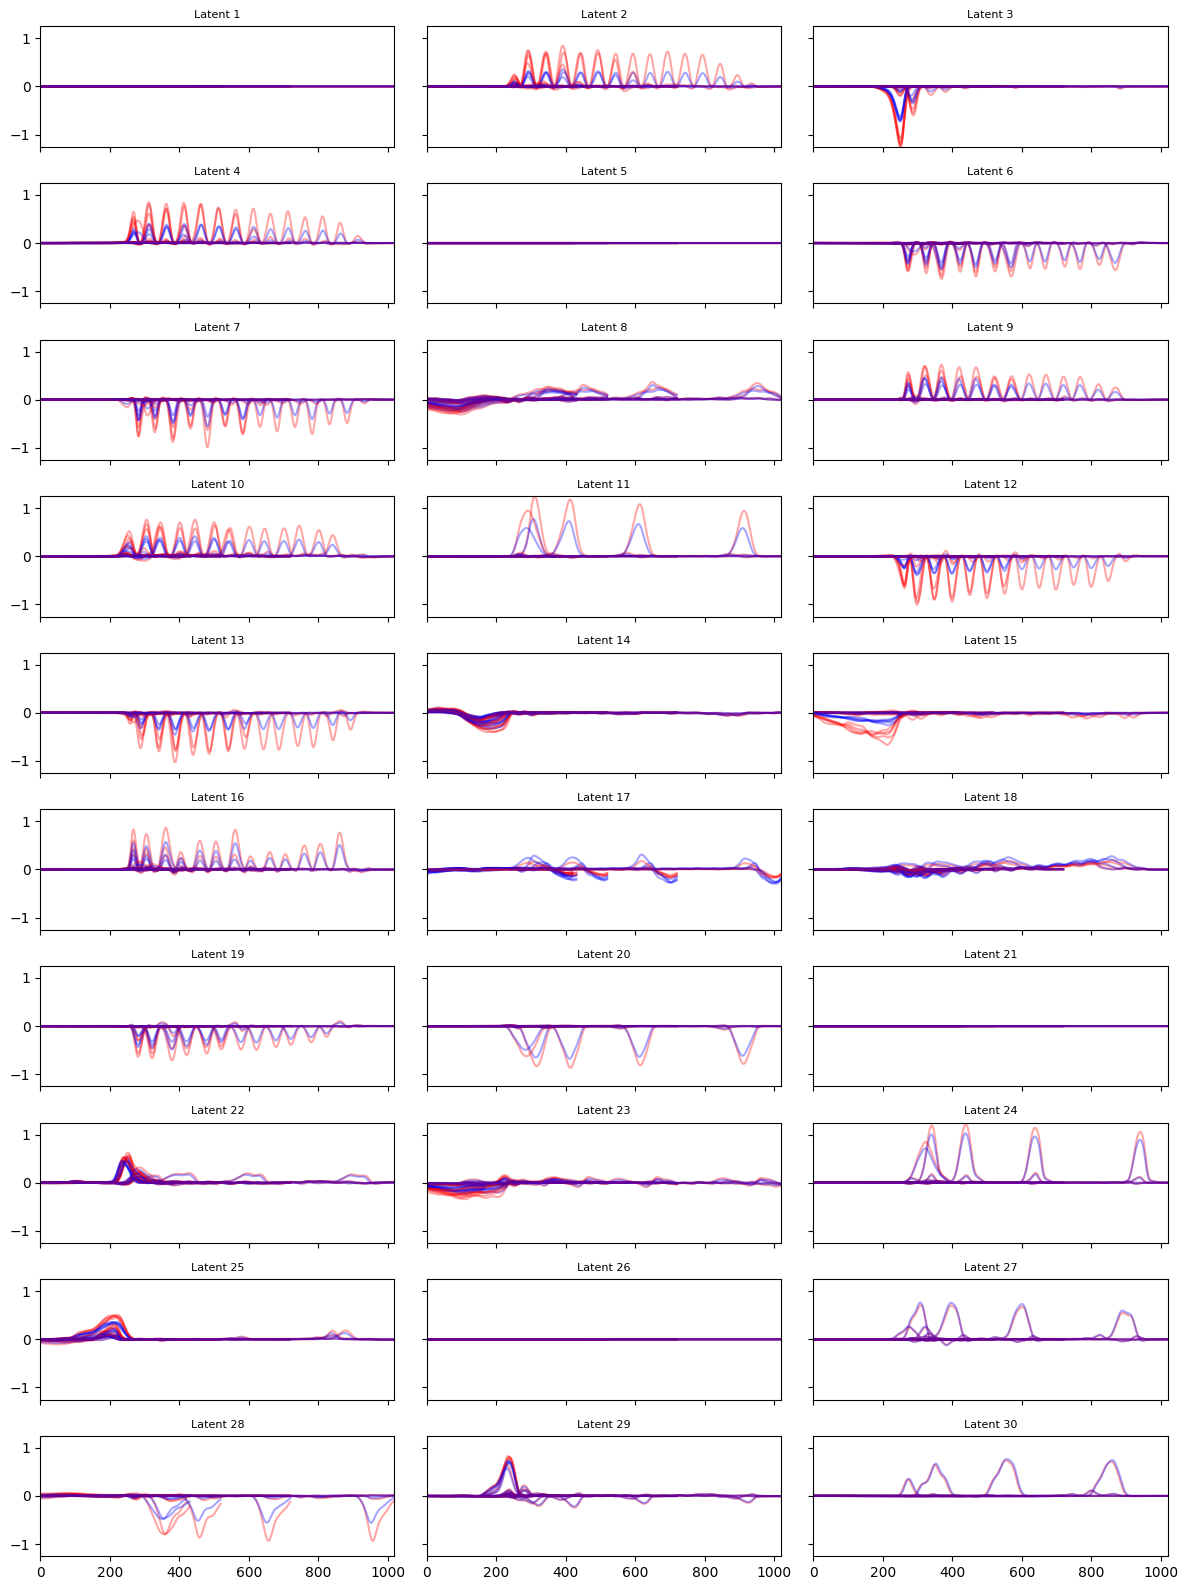

In [10]:
import torch
import torch._dynamo
import numpy as np
import matplotlib.pyplot as plt

torch._dynamo.config.suppress_errors = True

# get the learned latent trajectories of two regions 
# red is M1, blue is SMA
# there are 40 latent components in total, we will plot them all but only show the first 20 trials for visualization purposes
# plot everything on the same y-axis scale for easier comparison across components and regions
Z = msca.transform(X)

n_components = 30
# there are 20 trails for each region
n_trials = min(20, len(Z['M1']), len(Z['SMA']))

# Global y-range across all plotted traces so every subplot uses the same scale
all_vals = []
for j in range(n_trials):
    all_vals.append(Z['M1'][j][:, :n_components].ravel())
    all_vals.append(Z['SMA'][j][:, :n_components].ravel())
all_vals = np.concatenate(all_vals)
ymin, ymax = np.min(all_vals), np.max(all_vals)

# Global x-range across all plotted traces
max_t = max(max(Z['M1'][j].shape[0], Z['SMA'][j].shape[0]) for j in range(n_trials))

fig, axs = plt.subplots(10, 3, figsize=(12, 16), sharex=True, sharey=True)
for i in range(n_components): # plot each component in its own subplot
    ax = axs[i // 3, i % 3]
    for j in range(n_trials): # plot 20 trails per region on the same subplot
        ax.plot(Z['M1'][j][:, i], c='r', alpha=0.35)
        ax.plot(Z['SMA'][j][:, i], c='b', alpha=0.35)
    ax.set_xlim(0, max_t - 1)
    ax.set_ylim(ymin, ymax)
    ax.set_title(f'Latent {i + 1}', fontsize=8)

plt.tight_layout()
plt.show()

## Label the direction of each trail ( forward/backward)
## Without orthogonality

default lam_orthog =0.1

lam_orthog = 22.745220999701914

Direction mapping used: {-1: 'backward', 1: 'forward'}
trial  0: forward
trial  1: forward
trial  2: backward
trial  3: backward
trial  4: forward
trial  5: forward
trial  6: backward
trial  7: backward
trial  8: forward
trial  9: forward
trial 10: backward
trial 11: backward
trial 12: forward
trial 13: forward
trial 14: backward
trial 15: backward
trial 16: forward
trial 17: forward
trial 18: backward
trial 19: backward


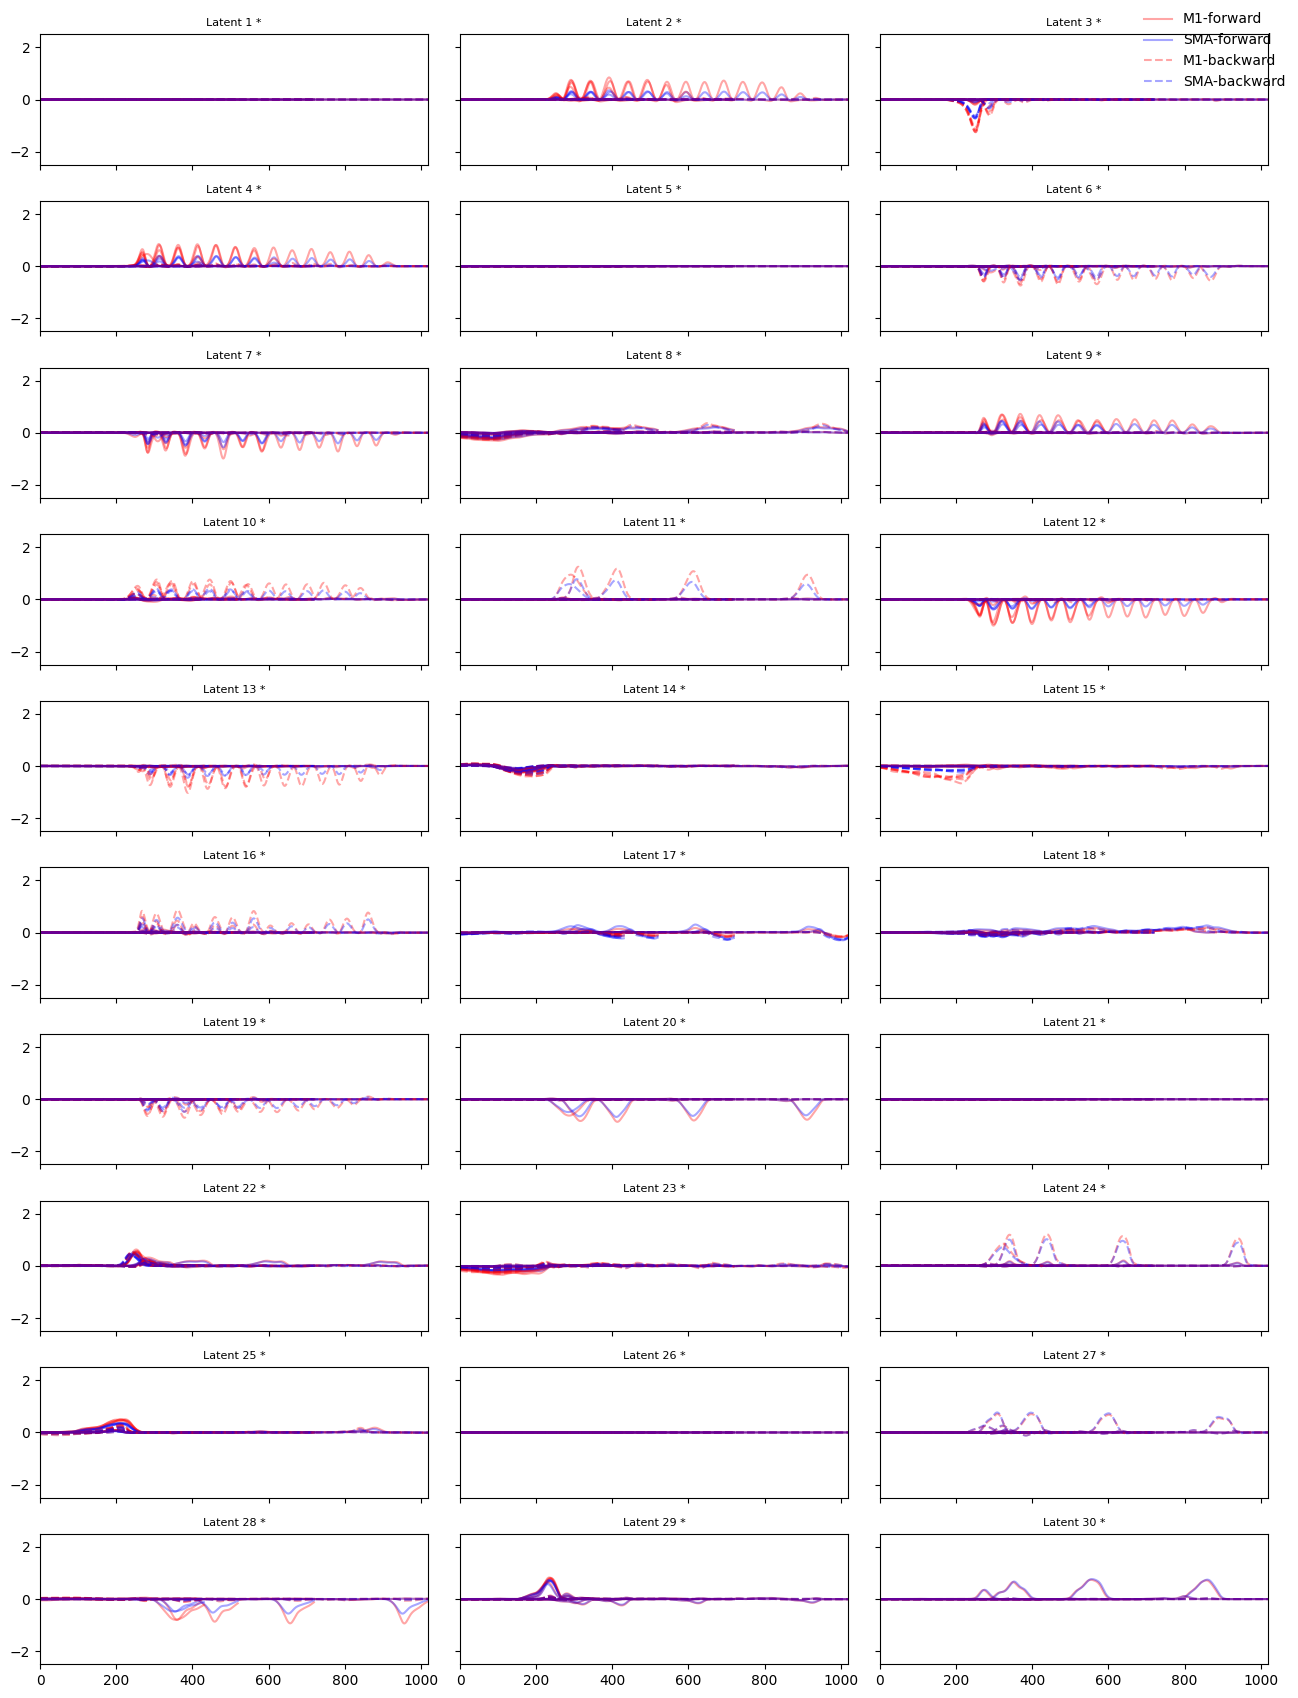

Number of subplots containing both forward and backward trials: 30
Component indices: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]


In [11]:
import torch
import torch._dynamo
import numpy as np
import matplotlib.pyplot as plt

torch._dynamo.config.suppress_errors = True

# ---- 1) get latents ----
Z = msca.transform(X)

n_components = 30
n_trials = min(20, len(Z["M1"]), len(Z["SMA"]))

# ---- 2) build trial direction labels from mask['dir'] ----
# forward vs backward cycling direction is encoded in m1_mask['dir']
dir_all = m1_mask["dir"][0, 0].squeeze()
start_idxs = np.asarray(m1_start_idxs).astype(int)
end_idxs = np.asarray(m1_end_idxs).astype(int)

trial_dir_value = []
for s, e in zip(start_idxs, end_idxs):
    d = dir_all[s:e]
    if d.size == 0:
        trial_dir_value.append(np.nan)
    else:
        u, c = np.unique(d, return_counts=True)
        trial_dir_value.append(u[np.argmax(c)])

trial_dir_value = np.asarray(trial_dir_value)

# Map numeric dir values -> text labels
valid_vals = np.unique(trial_dir_value[~np.isnan(trial_dir_value)])
if set(valid_vals.tolist()) == {-1, 1}:
    dir_map = {-1: "backward", 1: "forward"}
elif set(valid_vals.tolist()) == {0, 1}:
    dir_map = {0: "backward", 1: "forward"}
elif len(valid_vals) >= 2:
    vv = np.sort(valid_vals)
    dir_map = {vv[0]: "backward", vv[1]: "forward"}  # fallback
else:
    dir_map = {}

trial_dir_label = [dir_map.get(v, f"dir={v}") if not np.isnan(v) else "unknown" for v in trial_dir_value]

print("Direction mapping used:", dir_map)
for j in range(n_trials):
    print(f"trial {j:2d}: {trial_dir_label[j]}")

# ---- 3) global ranges ----
all_vals = []
for j in range(n_trials):
    all_vals.append(Z["M1"][j][:, :n_components].ravel())
    all_vals.append(Z["SMA"][j][:, :n_components].ravel())
all_vals = np.concatenate(all_vals)
ymin, ymax = np.min(all_vals), np.max(all_vals)
ymin, ymax = -2.5, 2.5  # for better visualization, can adjust as needed

max_t = max(max(Z["M1"][j].shape[0], Z["SMA"][j].shape[0]) for j in range(n_trials))

# ---- 4) plot + star-highlight components containing both directions ----
fig, axs = plt.subplots(10, 3, figsize=(13, 17), sharex=True, sharey=True)
legend_used = set()

both_dir_count = 0
both_dir_components = []

for i in range(n_components):
    ax = axs[i // 3, i % 3  ]
    has_forward = False
    has_backward = False

    for j in range(n_trials):
        lab = trial_dir_label[j]
        if lab == "forward":
            has_forward = True
        elif lab == "backward":
            has_backward = True

        ls = "-" if lab == "forward" else "--" if lab == "backward" else ":"

        key_m1 = ("M1", lab)
        key_sma = ("SMA", lab)
        label_m1 = f"M1-{lab}" if key_m1 not in legend_used else None
        label_sma = f"SMA-{lab}" if key_sma not in legend_used else None

        ax.plot(Z["M1"][j][:, i], c="r", alpha=0.35, ls=ls, label=label_m1)
        ax.plot(Z["SMA"][j][:, i], c="b", alpha=0.35, ls=ls, label=label_sma)

        if label_m1 is not None:
            legend_used.add(key_m1)
        if label_sma is not None:
            legend_used.add(key_sma)

    contains_both = has_forward and has_backward
    title = f"Latent {i + 1}" + (" *" if contains_both else "")
    ax.set_title(title, fontsize=8)

    if contains_both:
        both_dir_count += 1
        both_dir_components.append(i + 1)

    ax.set_xlim(0, max_t - 1)
    ax.set_ylim(ymin, ymax)

# one shared legend
handles, labels = axs[0, 0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc="upper right", frameon=False)

plt.tight_layout()
plt.show()
print(f"Number of subplots containing both forward and backward trials: {both_dir_count}")
print(f"Component indices: {both_dir_components}")

## Loss history

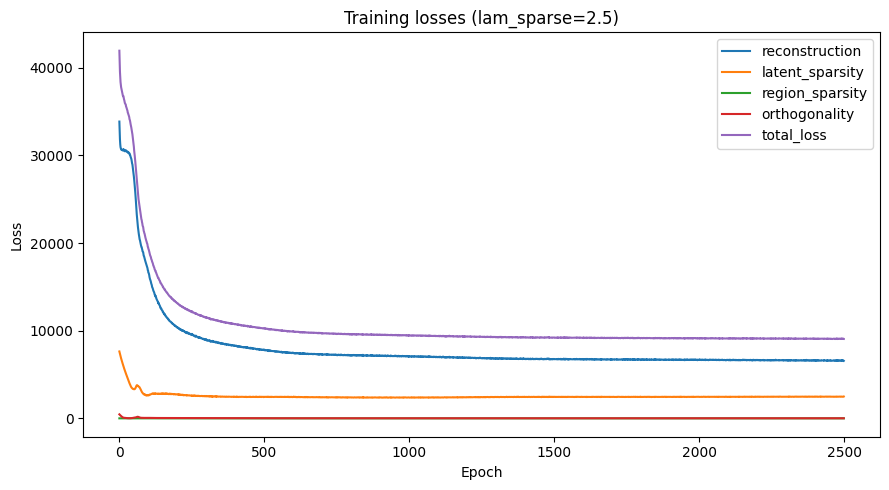

In [14]:
msca = mSCA(n_components=30, n_epochs=2500, loss_func="Gaussian", lr=1e-3, filter_len=41, linear=False, region_weights=None, lam_sparse=2.5, lam_orthog=0.1, lam_region=None, batch_size=64, cd_rate=0.5, decoder_type="triple_layer", post_hoc_epoch=-1)

model_fp = "./results/Cousteau/msca_TripleLayerDecoder.pt"
loss_fp = "./results/Cousteau/losses_TripleLayerDecoder.npz"

msca.load(model_fp, X)
losses = mSCA.load_losses(loss_fp)

plt.figure(figsize=(9, 5))
for name, vals in losses.items():
    plt.plot(vals, label=name)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training losses (lam_sparse=2.5)")
plt.legend()
plt.tight_layout()
plt.show()


## With orthognality 

lam_orthog =0.5

Using lam_orthog = 164.4685353631665

???
Using lam_sparse = 0.10868965220787684
Using lam_orthog = 164.46853536316652
Using lam_region = 0.0


In [26]:
# instantiate and fit mSCA model
# defualt lam_orthog is 0.1
msca = mSCA(n_components=40, n_epochs=10000, loss_func="Gaussian", lr=1e-3, filter_len=21, linear=False, region_weights=None, lam_sparse=2.5, lam_orthog=0.5, lam_region=None, batch_size=64, cd_rate=0.5, decoder_type="nonlinear", decoder_hidden_size=40, decoder_activation="GeLU", device="cpu", cd_mode="both", post_hoc_epoch=1000)
# load model parameters 
msca.load("./results/Cousteau/msca_cycling_NonlinearEncoder_NonlinearDecoder_Sparse2p5_LamOrthog0p5.pt", X)

Initialized mSCA with lam_sparse=2.5, lam_orthog=0.5, lam_region=None
Using region-weights = {'M1': 0.9075907851778412, 'SMA': 1.1133602846073158}
Using lam_sparse = 0.07783337798858116
Using lam_orthog = 113.72610499850956
Using lam_region = 0.0


Direction mapping used: {-1: 'backward', 1: 'forward'}
trial  0: forward
trial  1: forward
trial  2: backward
trial  3: backward
trial  4: forward
trial  5: forward
trial  6: backward
trial  7: backward
trial  8: forward
trial  9: forward
trial 10: backward
trial 11: backward
trial 12: forward
trial 13: forward
trial 14: backward
trial 15: backward
trial 16: forward
trial 17: forward
trial 18: backward
trial 19: backward


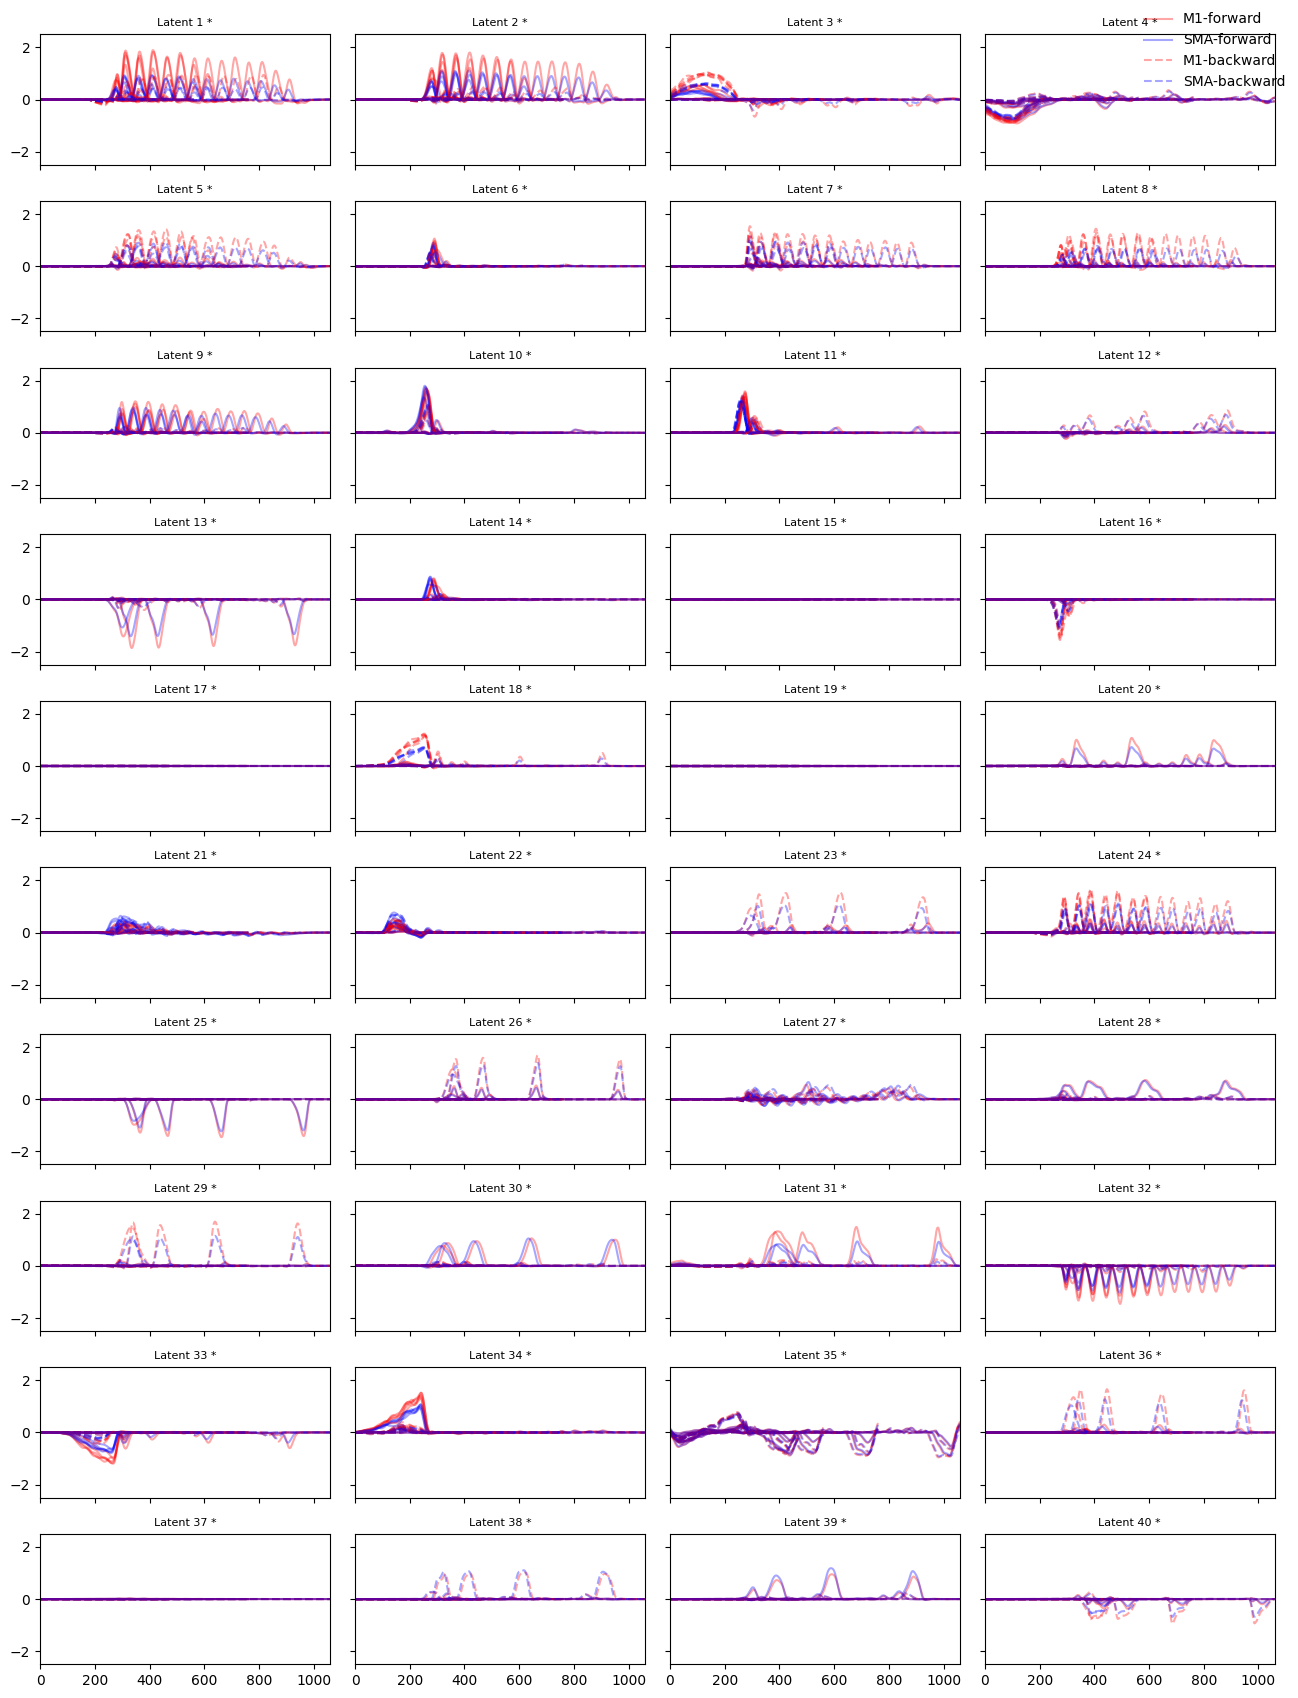

Number of subplots containing both forward and backward trials: 40
Component indices: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40]


In [27]:

# ---- 1) get latents ----
Z = msca.transform(X)

n_components = 40
n_trials = min(20, len(Z["M1"]), len(Z["SMA"]))

# ---- 2) build trial direction labels from mask['dir'] ----
# forward vs backward cycling direction is encoded in m1_mask['dir']
dir_all = m1_mask["dir"][0, 0].squeeze()
start_idxs = np.asarray(m1_start_idxs).astype(int)
end_idxs = np.asarray(m1_end_idxs).astype(int)

trial_dir_value = []
for s, e in zip(start_idxs, end_idxs):
    d = dir_all[s:e]
    if d.size == 0:
        trial_dir_value.append(np.nan)
    else:
        u, c = np.unique(d, return_counts=True)
        trial_dir_value.append(u[np.argmax(c)])

trial_dir_value = np.asarray(trial_dir_value)

# Map numeric dir values -> text labels
valid_vals = np.unique(trial_dir_value[~np.isnan(trial_dir_value)])
if set(valid_vals.tolist()) == {-1, 1}:
    dir_map = {-1: "backward", 1: "forward"}
elif set(valid_vals.tolist()) == {0, 1}:
    dir_map = {0: "backward", 1: "forward"}
elif len(valid_vals) >= 2:
    vv = np.sort(valid_vals)
    dir_map = {vv[0]: "backward", vv[1]: "forward"}  # fallback
else:
    dir_map = {}

trial_dir_label = [dir_map.get(v, f"dir={v}") if not np.isnan(v) else "unknown" for v in trial_dir_value]

print("Direction mapping used:", dir_map)
for j in range(n_trials):
    print(f"trial {j:2d}: {trial_dir_label[j]}")

# ---- 3) global ranges ----
all_vals = []
for j in range(n_trials):
    all_vals.append(Z["M1"][j][:, :n_components].ravel())
    all_vals.append(Z["SMA"][j][:, :n_components].ravel())
all_vals = np.concatenate(all_vals)
ymin, ymax = np.min(all_vals), np.max(all_vals)
ymin, ymax = -2.5, 2.5  # for better visualization, can adjust as needed
max_t = max(max(Z["M1"][j].shape[0], Z["SMA"][j].shape[0]) for j in range(n_trials))

# ---- 4) plot + star-highlight components containing both directions ----
fig, axs = plt.subplots(10, 4, figsize=(13, 17), sharex=True, sharey=True)
legend_used = set()

both_dir_count = 0
both_dir_components = []

for i in range(n_components):
    ax = axs[i // 4, i % 4]
    has_forward = False
    has_backward = False

    for j in range(n_trials):
        lab = trial_dir_label[j]
        if lab == "forward":
            has_forward = True
        elif lab == "backward":
            has_backward = True

        ls = "-" if lab == "forward" else "--" if lab == "backward" else ":"

        key_m1 = ("M1", lab)
        key_sma = ("SMA", lab)
        label_m1 = f"M1-{lab}" if key_m1 not in legend_used else None
        label_sma = f"SMA-{lab}" if key_sma not in legend_used else None

        ax.plot(Z["M1"][j][:, i], c="r", alpha=0.35, ls=ls, label=label_m1)
        ax.plot(Z["SMA"][j][:, i], c="b", alpha=0.35, ls=ls, label=label_sma)

        if label_m1 is not None:
            legend_used.add(key_m1)
        if label_sma is not None:
            legend_used.add(key_sma)

    contains_both = has_forward and has_backward
    title = f"Latent {i + 1}" + (" *" if contains_both else "")
    ax.set_title(title, fontsize=8)

    if contains_both:
        both_dir_count += 1
        both_dir_components.append(i + 1)

    ax.set_xlim(0, max_t - 1)
    ax.set_ylim(ymin, ymax)

# one shared legend
handles, labels = axs[0, 0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc="upper right", frameon=False)

plt.tight_layout()
plt.show()
print(f"Number of subplots containing both forward and backward trials: {both_dir_count}")
print(f"Component indices: {both_dir_components}")

### Loss History

Initialized mSCA with lam_sparse=2.5, lam_orthog=0.5, lam_region=None
Using region-weights = {'M1': 0.9075907851778412, 'SMA': 1.1133602846073158}
Using lam_sparse = 0.07783337798858116
Using lam_orthog = 113.72610499850956
Using lam_region = 0.0


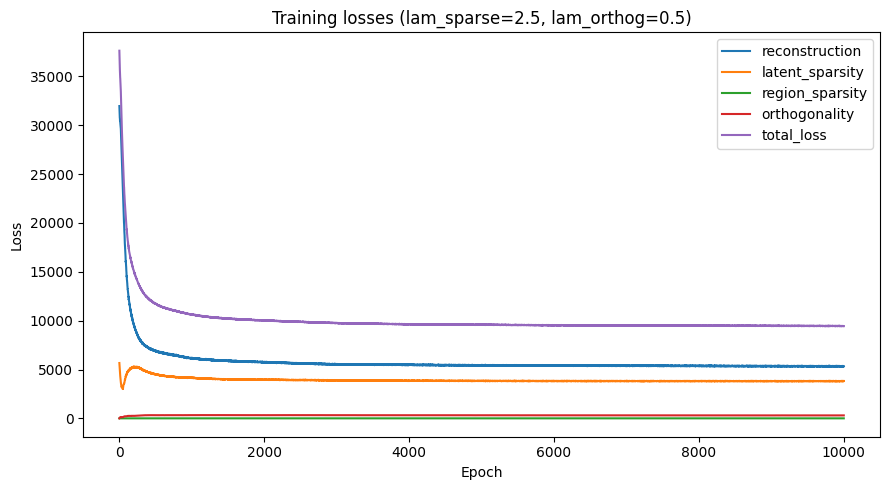

In [31]:

msca = mSCA(n_components=40, n_epochs=10000, loss_func="Gaussian", lr=1e-3, filter_len=21, linear=False, region_weights=None, lam_sparse=2.5, lam_orthog=0.5, lam_region=None, batch_size=64, cd_rate=0.5, decoder_type="nonlinear", decoder_hidden_size=40, decoder_activation="GeLU", device="cpu", cd_mode="both", post_hoc_epoch=1000)

model_fp = "./results/Cousteau/msca_cycling_NonlinearEncoder_NonlinearDecoder_Sparse2p5_LamOrthog0p5.pt"
loss_fp = "./results/Cousteau/losses_NonlinearEncoder_NonlinearDecoder_Sparse2p5_LamOrthog0p5.npz"

msca.load(model_fp, X)
losses = mSCA.load_losses(loss_fp)

plt.figure(figsize=(9, 5))
for name, vals in losses.items():
    plt.plot(vals, label=name)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training losses (lam_sparse=2.5, lam_orthog=0.5)")
plt.legend()
plt.tight_layout()
plt.show()



# Ramdom initialization 
using ramdom initialization 

using defualt orthogonality lam

using lam_sparse=2.5

In [9]:
# instantiate and fit mSCA model

msca = mSCA(n_components=40, n_epochs=10000, loss_func="Gaussian", lr=1e-3, filter_len=21, linear=False, region_weights=None, lam_sparse=2.5, lam_orthog=None, lam_region=None, batch_size=64, cd_rate=0.5, decoder_type="nonlinear", decoder_hidden_size=40,decoder_init_mode = "random", decoder_activation="GeLU", device="cpu", cd_mode="both", post_hoc_epoch=1000)
# load model parameters 
msca.load("./results/Cousteau/msca_cycling_NonlinearEncoder_NonlinearDecoder_Sparse2p5_randomInit.pt", X)

Initialized mSCA with lam_sparse=2.5, lam_orthog=None, lam_region=None
Using region-weights = {'M1': 0.9075907851778412, 'SMA': 1.1133602846073158}
Using lam_sparse = 0.07783337798858116
Using lam_orthog = 22.745220999701914
Using lam_region = 0.0


Direction mapping used: {-1: 'backward', 1: 'forward'}
trial  0: forward
trial  1: forward
trial  2: backward
trial  3: backward
trial  4: forward
trial  5: forward
trial  6: backward
trial  7: backward
trial  8: forward
trial  9: forward
trial 10: backward
trial 11: backward
trial 12: forward
trial 13: forward
trial 14: backward
trial 15: backward
trial 16: forward
trial 17: forward
trial 18: backward
trial 19: backward


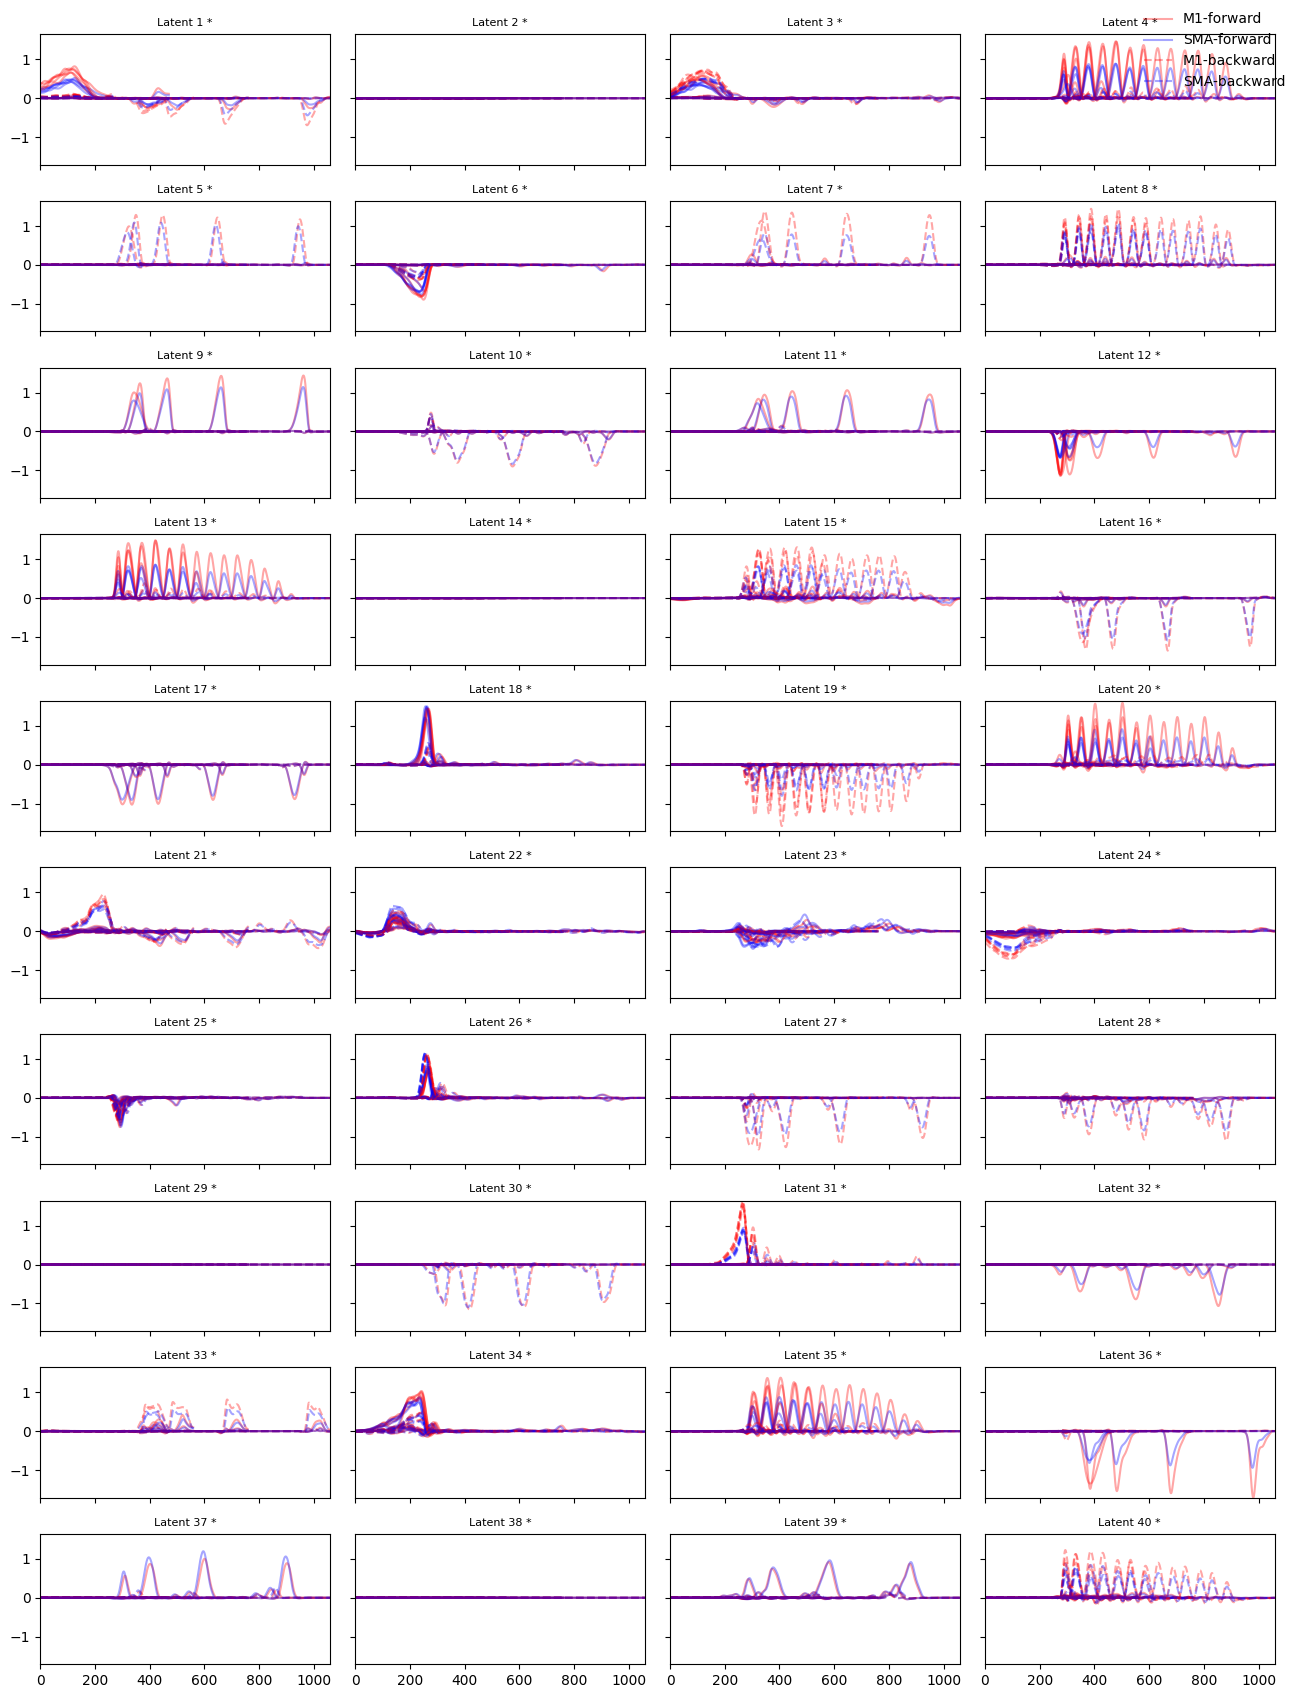

Number of subplots containing both forward and backward trials: 40
Component indices: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40]


In [10]:


# ---- 1) get latents ----
Z = msca.transform(X)

n_components = 40
n_trials = min(20, len(Z["M1"]), len(Z["SMA"]))

# ---- 2) build trial direction labels from mask['dir'] ----
# forward vs backward cycling direction is encoded in m1_mask['dir']
dir_all = m1_mask["dir"][0, 0].squeeze()
start_idxs = np.asarray(m1_start_idxs).astype(int)
end_idxs = np.asarray(m1_end_idxs).astype(int)

trial_dir_value = []
for s, e in zip(start_idxs, end_idxs):
    d = dir_all[s:e]
    if d.size == 0:
        trial_dir_value.append(np.nan)
    else:
        u, c = np.unique(d, return_counts=True)
        trial_dir_value.append(u[np.argmax(c)])

trial_dir_value = np.asarray(trial_dir_value)

# Map numeric dir values -> text labels
valid_vals = np.unique(trial_dir_value[~np.isnan(trial_dir_value)])
if set(valid_vals.tolist()) == {-1, 1}:
    dir_map = {-1: "backward", 1: "forward"}
elif set(valid_vals.tolist()) == {0, 1}:
    dir_map = {0: "backward", 1: "forward"}
elif len(valid_vals) >= 2:
    vv = np.sort(valid_vals)
    dir_map = {vv[0]: "backward", vv[1]: "forward"}  # fallback
else:
    dir_map = {}

trial_dir_label = [dir_map.get(v, f"dir={v}") if not np.isnan(v) else "unknown" for v in trial_dir_value]

print("Direction mapping used:", dir_map)
for j in range(n_trials):
    print(f"trial {j:2d}: {trial_dir_label[j]}")

# ---- 3) global ranges ----
all_vals = []
for j in range(n_trials):
    all_vals.append(Z["M1"][j][:, :n_components].ravel())
    all_vals.append(Z["SMA"][j][:, :n_components].ravel())
all_vals = np.concatenate(all_vals)
ymin, ymax = np.min(all_vals), np.max(all_vals)

max_t = max(max(Z["M1"][j].shape[0], Z["SMA"][j].shape[0]) for j in range(n_trials))

# ---- 4) plot + star-highlight components containing both directions ----
fig, axs = plt.subplots(10, 4, figsize=(13, 17), sharex=True, sharey=True)
legend_used = set()

both_dir_count = 0
both_dir_components = []

for i in range(n_components):
    ax = axs[i // 4, i % 4]
    has_forward = False
    has_backward = False

    for j in range(n_trials):
        lab = trial_dir_label[j]
        if lab == "forward":
            has_forward = True
        elif lab == "backward":
            has_backward = True

        ls = "-" if lab == "forward" else "--" if lab == "backward" else ":"

        key_m1 = ("M1", lab)
        key_sma = ("SMA", lab)
        label_m1 = f"M1-{lab}" if key_m1 not in legend_used else None
        label_sma = f"SMA-{lab}" if key_sma not in legend_used else None

        ax.plot(Z["M1"][j][:, i], c="r", alpha=0.35, ls=ls, label=label_m1)
        ax.plot(Z["SMA"][j][:, i], c="b", alpha=0.35, ls=ls, label=label_sma)

        if label_m1 is not None:
            legend_used.add(key_m1)
        if label_sma is not None:
            legend_used.add(key_sma)

    contains_both = has_forward and has_backward
    title = f"Latent {i + 1}" + (" *" if contains_both else "")
    ax.set_title(title, fontsize=8)

    if contains_both:
        both_dir_count += 1
        both_dir_components.append(i + 1)

    ax.set_xlim(0, max_t - 1)
    ax.set_ylim(ymin, ymax)

# one shared legend
handles, labels = axs[0, 0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc="upper right", frameon=False)

plt.tight_layout()
plt.show()
print(f"Number of subplots containing both forward and backward trials: {both_dir_count}")
print(f"Component indices: {both_dir_components}")

Initialized mSCA with lam_sparse=None, lam_orthog=None, lam_region=None
Using region-weights = {'M1': 0.9075907851778412, 'SMA': 1.1133602846073158}
Using lam_sparse = 0.031133351195432462
Using lam_orthog = 22.745220999701914
Using lam_region = 0.0


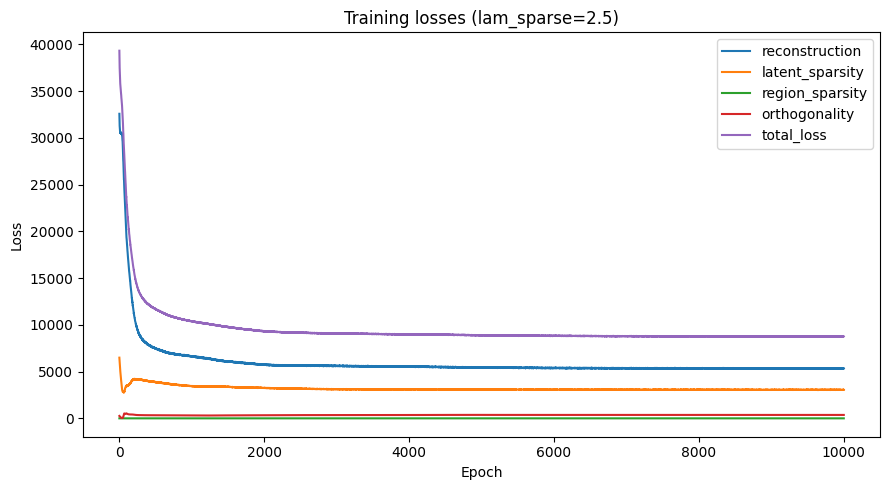

In [11]:

msca = mSCA(n_components=40, n_epochs=10000, loss_func="Gaussian", lr=1e-3, filter_len=21, linear=False, region_weights=None, lam_sparse=None, lam_orthog=None, lam_region=None, batch_size=64, cd_rate=0.5, decoder_type="nonlinear", decoder_hidden_size=40, decoder_activation="GeLU", device="cpu", cd_mode="both", post_hoc_epoch=1000)

model_fp = "./results/Cousteau/msca_cycling_NonlinearEncoder_NonlinearDecoder_Sparse2p5_randomInit.pt"
loss_fp = "./results/Cousteau/losses_NonlinearEncoder_NonlinearDecoder_Sparse2p5_randomInit.npz"

msca.load(model_fp, X)
losses = mSCA.load_losses(loss_fp)

plt.figure(figsize=(9, 5))
for name, vals in losses.items():
    plt.plot(vals, label=name)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training losses (lam_sparse=2.5)")
plt.legend()
plt.tight_layout()
plt.show()



# Adaptive


In [5]:
# instantiate and fit mSCA model

msca = mSCA(n_components=40, n_epochs=10000, loss_func="Gaussian", lr=1e-3, filter_len=21, linear=False, region_weights=None, lam_sparse="adaptive", lam_orthog=None, lam_region=None, batch_size=64, cd_rate=0.5, decoder_type="nonlinear", decoder_hidden_size=40,decoder_init_mode = "pca", decoder_activation="GeLU", device="cpu", cd_mode="both", post_hoc_epoch=1000)
# load model parameters 
msca.load("./results/Cousteau/msca_cycling_NonlinearEncoder_NonlinearDecoder_AdaptiveSparse.pt", X)

Initialized mSCA with lam_sparse=adaptive, lam_orthog=None, lam_region=None
passed lam_orthog: None
Using region-weights = {'M1': 0.9075907851778412, 'SMA': 1.1133602846073158}
Using lam_sparse = adaptive
Using lam_orthog = 22.745220999701914
Using lam_region = 0.0
Checkpoint training hyperparameters:
  lam_sparse  = 0.43951356410980225
  lam_orthog  = 32.89370707263331
  lam_region  = 0.0
  region_weights = {'M1': 0.8072827155633928, 'SMA': 1.31358302090514}


Direction mapping used: {-1: 'backward', 1: 'forward'}
trial  0: forward
trial  1: forward
trial  2: backward
trial  3: backward
trial  4: forward
trial  5: forward
trial  6: backward
trial  7: backward
trial  8: forward
trial  9: forward
trial 10: backward
trial 11: backward
trial 12: forward
trial 13: forward
trial 14: backward
trial 15: backward
trial 16: forward
trial 17: forward
trial 18: backward
trial 19: backward


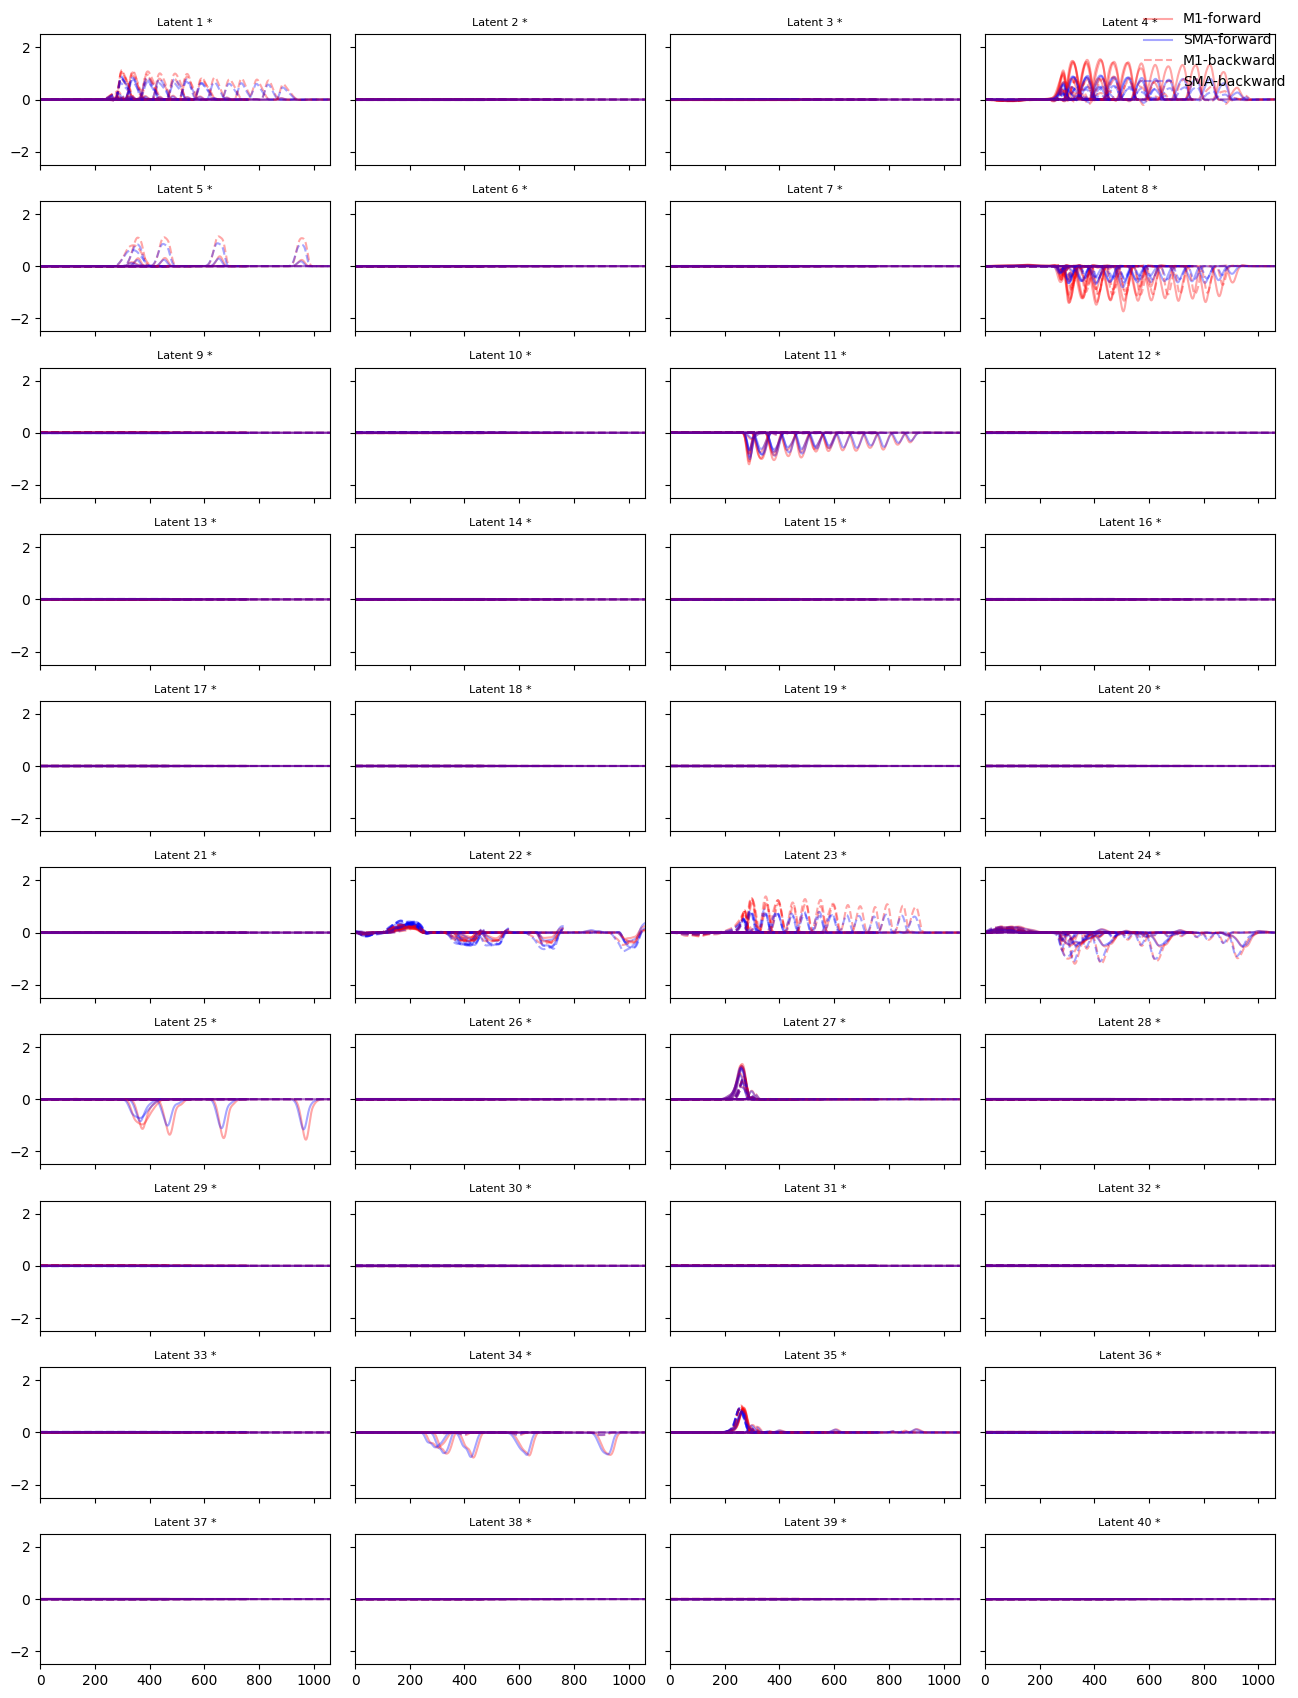

Number of subplots containing both forward and backward trials: 40
Component indices: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40]


In [8]:


# ---- 1) get latents ----
Z = msca.transform(X)

n_components = 40
n_trials = min(20, len(Z["M1"]), len(Z["SMA"]))

# ---- 2) build trial direction labels from mask['dir'] ----
# forward vs backward cycling direction is encoded in m1_mask['dir']
dir_all = m1_mask["dir"][0, 0].squeeze()
start_idxs = np.asarray(m1_start_idxs).astype(int)
end_idxs = np.asarray(m1_end_idxs).astype(int)

trial_dir_value = []
for s, e in zip(start_idxs, end_idxs):
    d = dir_all[s:e]
    if d.size == 0:
        trial_dir_value.append(np.nan)
    else:
        u, c = np.unique(d, return_counts=True)
        trial_dir_value.append(u[np.argmax(c)])

trial_dir_value = np.asarray(trial_dir_value)

# Map numeric dir values -> text labels
valid_vals = np.unique(trial_dir_value[~np.isnan(trial_dir_value)])
if set(valid_vals.tolist()) == {-1, 1}:
    dir_map = {-1: "backward", 1: "forward"}
elif set(valid_vals.tolist()) == {0, 1}:
    dir_map = {0: "backward", 1: "forward"}
elif len(valid_vals) >= 2:
    vv = np.sort(valid_vals)
    dir_map = {vv[0]: "backward", vv[1]: "forward"}  # fallback
else:
    dir_map = {}

trial_dir_label = [dir_map.get(v, f"dir={v}") if not np.isnan(v) else "unknown" for v in trial_dir_value]

print("Direction mapping used:", dir_map)
for j in range(n_trials):
    print(f"trial {j:2d}: {trial_dir_label[j]}")

# ---- 3) global ranges ----
all_vals = []
for j in range(n_trials):
    all_vals.append(Z["M1"][j][:, :n_components].ravel())
    all_vals.append(Z["SMA"][j][:, :n_components].ravel())
all_vals = np.concatenate(all_vals)
ymin, ymax = np.min(all_vals), np.max(all_vals)
ymin, ymax = -2.5, 2.5  # for better visualization, can adjust as needed

max_t = max(max(Z["M1"][j].shape[0], Z["SMA"][j].shape[0]) for j in range(n_trials))

# ---- 4) plot + star-highlight components containing both directions ----
fig, axs = plt.subplots(10, 4, figsize=(13, 17), sharex=True, sharey=True)
legend_used = set()

both_dir_count = 0
both_dir_components = []

for i in range(n_components):
    ax = axs[i // 4, i % 4]
    has_forward = False
    has_backward = False

    for j in range(n_trials):
        lab = trial_dir_label[j]
        if lab == "forward":
            has_forward = True
        elif lab == "backward":
            has_backward = True

        ls = "-" if lab == "forward" else "--" if lab == "backward" else ":"

        key_m1 = ("M1", lab)
        key_sma = ("SMA", lab)
        label_m1 = f"M1-{lab}" if key_m1 not in legend_used else None
        label_sma = f"SMA-{lab}" if key_sma not in legend_used else None

        ax.plot(Z["M1"][j][:, i], c="r", alpha=0.35, ls=ls, label=label_m1)
        ax.plot(Z["SMA"][j][:, i], c="b", alpha=0.35, ls=ls, label=label_sma)

        if label_m1 is not None:
            legend_used.add(key_m1)
        if label_sma is not None:
            legend_used.add(key_sma)

    contains_both = has_forward and has_backward
    title = f"Latent {i + 1}" + (" *" if contains_both else "")
    ax.set_title(title, fontsize=8)

    if contains_both:
        both_dir_count += 1
        both_dir_components.append(i + 1)

    ax.set_xlim(0, max_t - 1)
    ax.set_ylim(ymin, ymax)

# one shared legend
handles, labels = axs[0, 0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc="upper right", frameon=False)

plt.tight_layout()
plt.show()
print(f"Number of subplots containing both forward and backward trials: {both_dir_count}")
print(f"Component indices: {both_dir_components}")

Initialized mSCA with lam_sparse=adaptive, lam_orthog=None, lam_region=None
passed lam_orthog: None
Using region-weights = {'M1': 0.9075907851778412, 'SMA': 1.1133602846073158}
Using lam_sparse = adaptive
Using lam_orthog = 22.745220999701914
Using lam_region = 0.0
Checkpoint training hyperparameters:
  lam_sparse  = 0.43951356410980225
  lam_orthog  = 32.89370707263331
  lam_region  = 0.0
  region_weights = {'M1': 0.8072827155633928, 'SMA': 1.31358302090514}


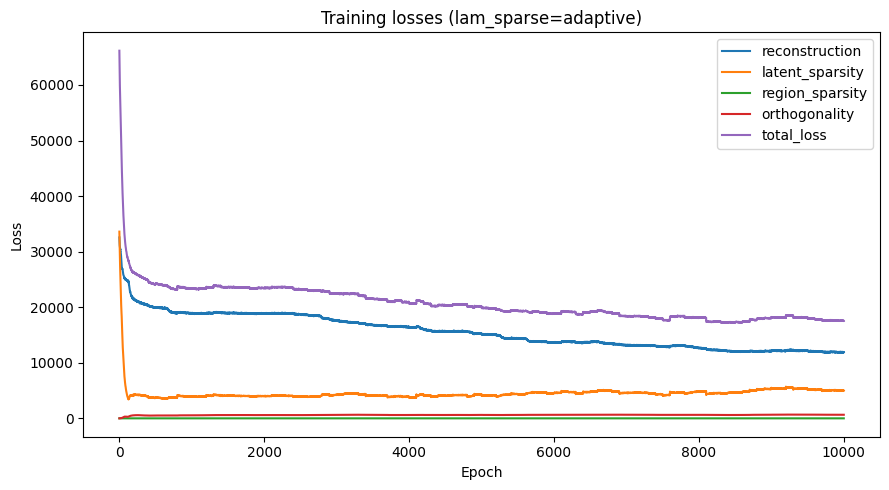

In [7]:

msca = mSCA(n_components=40, n_epochs=10000, loss_func="Gaussian", lr=1e-3, filter_len=21, linear=False, region_weights=None, lam_sparse="adaptive", lam_orthog=None, lam_region=None, batch_size=64, cd_rate=0.5, decoder_type="nonlinear", decoder_hidden_size=40, decoder_activation="GeLU", device="cpu", cd_mode="both", post_hoc_epoch=1000)

model_fp = "./results/Cousteau/msca_cycling_NonlinearEncoder_NonlinearDecoder_AdaptiveSparse.pt"
loss_fp = "./results/Cousteau/losses_NonlinearEncoder_NonlinearDecoder_AdaptiveSparse.npz"

msca.load(model_fp, X)
losses = mSCA.load_losses(loss_fp)

plt.figure(figsize=(9, 5))
for name, vals in losses.items():
    plt.plot(vals, label=name)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training losses (lam_sparse=adaptive)")
plt.legend()
plt.tight_layout()
plt.show()



# No orthognality panelty 
lam_orth =0


In [6]:
# instantiate and fit mSCA model
# defualt lam_orthog is 0
msca = mSCA(n_components=40, n_epochs=10000, loss_func="Gaussian", lr=1e-3, filter_len=21, linear=False, region_weights=None, lam_sparse=2.5, lam_orthog=0, lam_region=None, batch_size=64, cd_rate=0.5, decoder_type="nonlinear", decoder_hidden_size=40, decoder_activation="GeLU", device="cpu", cd_mode="both", post_hoc_epoch=1000)
# load model parameters 
msca.load("./results/Cousteau/msca_cycling_NonlinearEncoder_NonlinearDecoder_Sparse2p5_LamOrthog0p0.pt", X)

Initialized mSCA with lam_sparse=2.5, lam_orthog=0, lam_region=None
passed lam_sparse: 2.5
passed lam_orthog: 0
Using region-weights = {'M1': 0.9075907851778412, 'SMA': 1.1133602846073158}
Using lam_sparse = 0.07783337798858116
Using lam_orthog = 0.0
Using lam_region = 0.0
Checkpoint training hyperparameters:
  lam_sparse  = 0.10868965220787678
  lam_orthog  = 0.0
  lam_region  = 0.0
  region_weights = {'M1': 0.8072827155633927, 'SMA': 1.3135830209051405}


Direction mapping used: {-1: 'backward', 1: 'forward'}
trial  0: forward
trial  1: forward
trial  2: backward
trial  3: backward
trial  4: forward
trial  5: forward
trial  6: backward
trial  7: backward
trial  8: forward
trial  9: forward
trial 10: backward
trial 11: backward
trial 12: forward
trial 13: forward
trial 14: backward
trial 15: backward
trial 16: forward
trial 17: forward
trial 18: backward
trial 19: backward


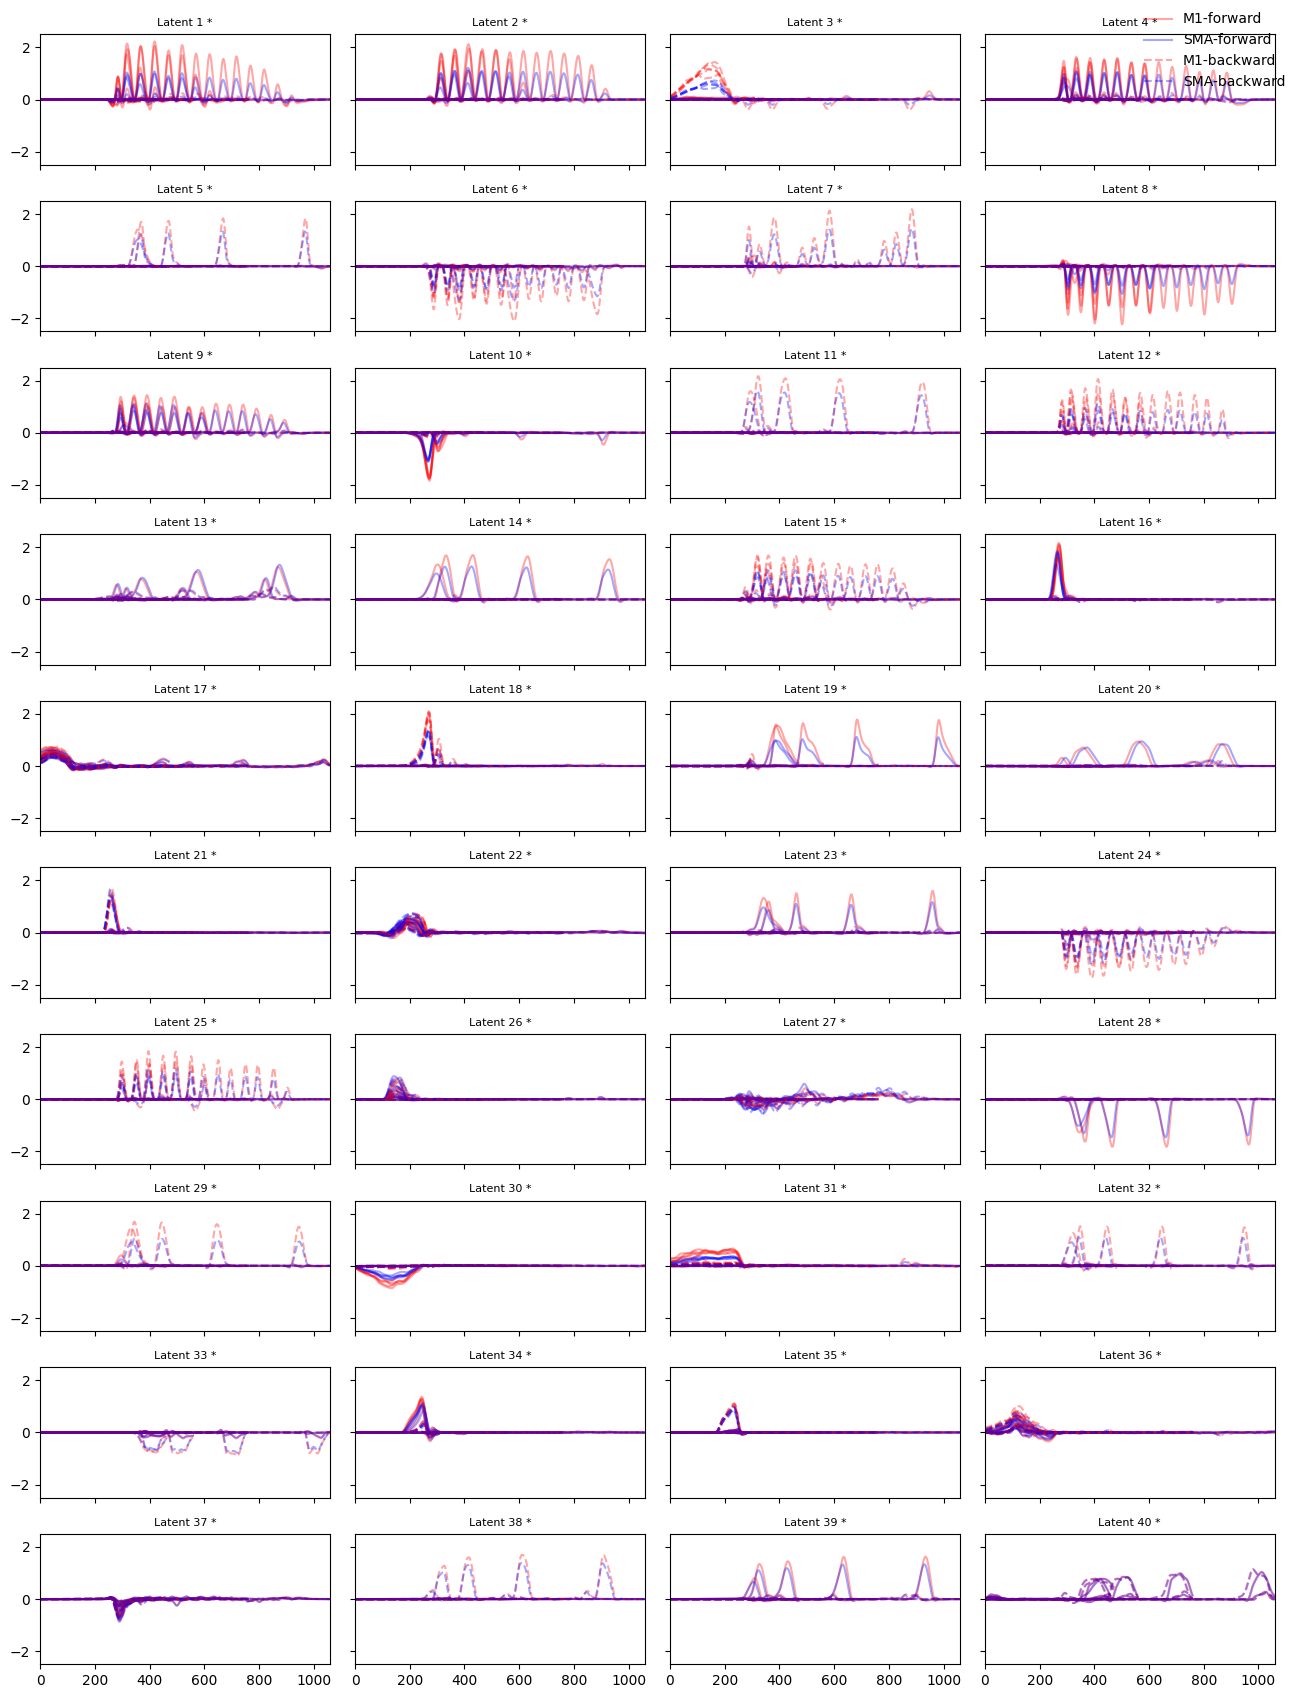

Number of subplots containing both forward and backward trials: 40
Component indices: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40]


In [7]:

# ---- 1) get latents ----
Z = msca.transform(X)

n_components = 40
n_trials = min(20, len(Z["M1"]), len(Z["SMA"]))

# ---- 2) build trial direction labels from mask['dir'] ----
# forward vs backward cycling direction is encoded in m1_mask['dir']
dir_all = m1_mask["dir"][0, 0].squeeze()
start_idxs = np.asarray(m1_start_idxs).astype(int)
end_idxs = np.asarray(m1_end_idxs).astype(int)

trial_dir_value = []
for s, e in zip(start_idxs, end_idxs):
    d = dir_all[s:e]
    if d.size == 0:
        trial_dir_value.append(np.nan)
    else:
        u, c = np.unique(d, return_counts=True)
        trial_dir_value.append(u[np.argmax(c)])

trial_dir_value = np.asarray(trial_dir_value)

# Map numeric dir values -> text labels
valid_vals = np.unique(trial_dir_value[~np.isnan(trial_dir_value)])
if set(valid_vals.tolist()) == {-1, 1}:
    dir_map = {-1: "backward", 1: "forward"}
elif set(valid_vals.tolist()) == {0, 1}:
    dir_map = {0: "backward", 1: "forward"}
elif len(valid_vals) >= 2:
    vv = np.sort(valid_vals)
    dir_map = {vv[0]: "backward", vv[1]: "forward"}  # fallback
else:
    dir_map = {}

trial_dir_label = [dir_map.get(v, f"dir={v}") if not np.isnan(v) else "unknown" for v in trial_dir_value]

print("Direction mapping used:", dir_map)
for j in range(n_trials):
    print(f"trial {j:2d}: {trial_dir_label[j]}")

# ---- 3) global ranges ----
all_vals = []
for j in range(n_trials):
    all_vals.append(Z["M1"][j][:, :n_components].ravel())
    all_vals.append(Z["SMA"][j][:, :n_components].ravel())
all_vals = np.concatenate(all_vals)
ymin, ymax = np.min(all_vals), np.max(all_vals)
ymin, ymax = -2.5, 2.5  # for better visualization, can adjust as needed
max_t = max(max(Z["M1"][j].shape[0], Z["SMA"][j].shape[0]) for j in range(n_trials))

# ---- 4) plot + star-highlight components containing both directions ----
fig, axs = plt.subplots(10, 4, figsize=(13, 17), sharex=True, sharey=True)
legend_used = set()

both_dir_count = 0
both_dir_components = []

for i in range(n_components):
    ax = axs[i // 4, i % 4]
    has_forward = False
    has_backward = False

    for j in range(n_trials):
        lab = trial_dir_label[j]
        if lab == "forward":
            has_forward = True
        elif lab == "backward":
            has_backward = True

        ls = "-" if lab == "forward" else "--" if lab == "backward" else ":"

        key_m1 = ("M1", lab)
        key_sma = ("SMA", lab)
        label_m1 = f"M1-{lab}" if key_m1 not in legend_used else None
        label_sma = f"SMA-{lab}" if key_sma not in legend_used else None

        ax.plot(Z["M1"][j][:, i], c="r", alpha=0.35, ls=ls, label=label_m1)
        ax.plot(Z["SMA"][j][:, i], c="b", alpha=0.35, ls=ls, label=label_sma)

        if label_m1 is not None:
            legend_used.add(key_m1)
        if label_sma is not None:
            legend_used.add(key_sma)

    contains_both = has_forward and has_backward
    title = f"Latent {i + 1}" + (" *" if contains_both else "")
    ax.set_title(title, fontsize=8)

    if contains_both:
        both_dir_count += 1
        both_dir_components.append(i + 1)

    ax.set_xlim(0, max_t - 1)
    ax.set_ylim(ymin, ymax)

# one shared legend
handles, labels = axs[0, 0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc="upper right", frameon=False)

plt.tight_layout()
plt.show()
print(f"Number of subplots containing both forward and backward trials: {both_dir_count}")
print(f"Component indices: {both_dir_components}")

Initialized mSCA with lam_sparse=2.5, lam_orthog=0, lam_region=None
passed lam_sparse: 2.5
passed lam_orthog: 0
Using region-weights = {'M1': 0.9075907851778412, 'SMA': 1.1133602846073158}
Using lam_sparse = 0.07783337798858116
Using lam_orthog = 0.0
Using lam_region = 0.0
Checkpoint training hyperparameters:
  lam_sparse  = 0.10868965220787678
  lam_orthog  = 0.0
  lam_region  = 0.0
  region_weights = {'M1': 0.8072827155633927, 'SMA': 1.3135830209051405}


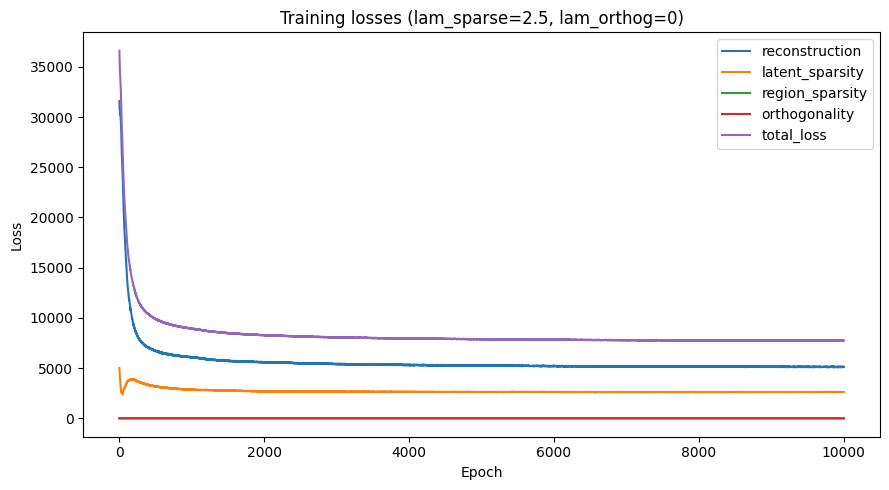

In [8]:

msca = mSCA(n_components=40, n_epochs=10000, loss_func="Gaussian", lr=1e-3, filter_len=21, linear=False, region_weights=None, lam_sparse=2.5, lam_orthog=0, lam_region=None, batch_size=64, cd_rate=0.5, decoder_type="nonlinear", decoder_hidden_size=40, decoder_activation="GeLU", device="cpu", cd_mode="both", post_hoc_epoch=1000)

model_fp = "./results/Cousteau/msca_cycling_NonlinearEncoder_NonlinearDecoder_Sparse2p5_LamOrthog0p0.pt"
loss_fp = "./results/Cousteau/losses_NonlinearEncoder_NonlinearDecoder_Sparse2p5_LamOrthog0p0.npz"

msca.load(model_fp, X)
losses = mSCA.load_losses(loss_fp)

plt.figure(figsize=(9, 5))
for name, vals in losses.items():
    plt.plot(vals, label=name)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training losses (lam_sparse=2.5, lam_orthog=0)")
plt.legend()
plt.tight_layout()
plt.show()



# Orthognality of Effective matrix: lam_orth = 0.1

dict_keys(['state_dict', 'effective_decoder', 'effective_decoder_by_region', 'meta'])
W_eff shape: (193, 40)
M1 (116, 40)
SMA (77, 40)
Decoder product shape: (40, 40)


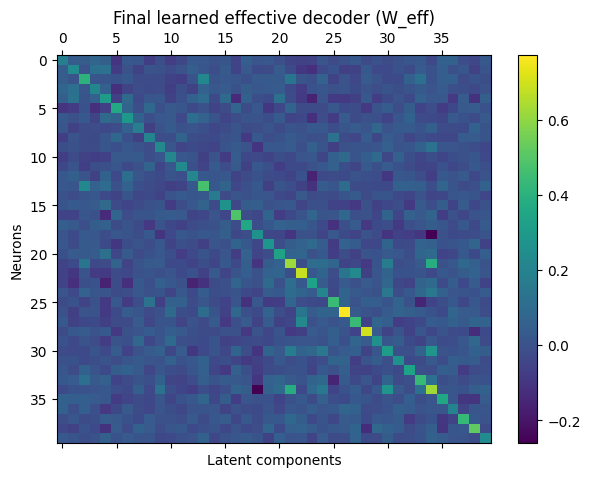

In [20]:

ckpt_path = "./results/Cousteau/msca_cycling_NonlinearEncoder_NonlinearDecoder_Sparse2p5_LamOrthog0p1_effw.pt"
ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)

print(ckpt.keys())  # check available fields

W_eff = ckpt["effective_decoder"]                    # full matrix
W_eff_by_region = ckpt["effective_decoder_by_region"]  # dict by region

print("W_eff shape:", tuple(W_eff.shape))
for k, w in W_eff_by_region.items():
    print(k, tuple(w.shape))

decoder_product = W_eff_by_region["SMA"].detach().cpu().numpy()  # safe for plotting

A= decoder_product.T @ decoder_product
print("Decoder product shape:", A.shape)

plt.figure(figsize=(7, 5))
plt.matshow(A, fignum=1, cmap="viridis", aspect="auto")
plt.colorbar()
plt.title("Final learned effective decoder (W_eff)")
plt.xlabel("Latent components")
plt.ylabel("Neurons")
plt.show()



## Nonlinear Encoder Nonlinear Decoder: Summarise and Plot Results


## Nonlinear Encoder Nonlinear Decoder: Summarise and Plot Results


# Orthognality of Effective matrix: lam_orth = 0.0

dict_keys(['state_dict', 'effective_decoder', 'effective_decoder_by_region', 'meta'])
W_eff shape: (193, 40)
M1 (116, 40)
SMA (77, 40)
Hidden layer weight shape:(H,C)
Output layer weight shape:(N,C)
Decoder product shape:(N,C) (77, 40)
Decoder product.T @ decoder_product shape:(C,C)
Decoder product shape: (40, 40)


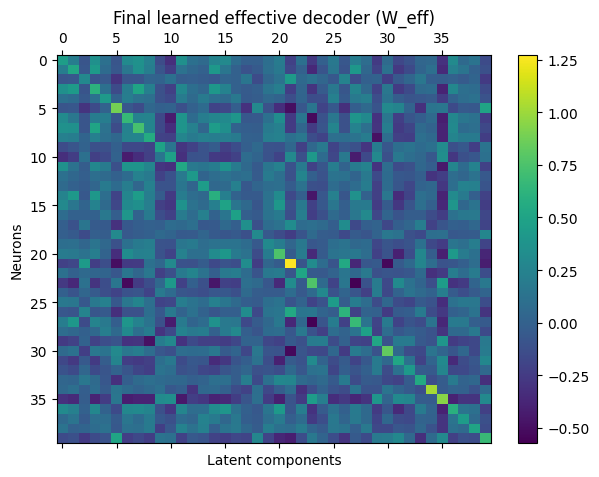

In [22]:

ckpt_path = "./results/Cousteau/msca_cycling_NonlinearEncoder_NonlinearDecoder_Sparse2p5_LamOrthog0p0_effw.pt"
ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)

print(ckpt.keys())  # check available fields

W_eff = ckpt["effective_decoder"]                    # full matrix
W_eff_by_region = ckpt["effective_decoder_by_region"]  # dict by region

print("W_eff shape:", tuple(W_eff.shape))
for k, w in W_eff_by_region.items():
    print(k, tuple(w.shape))

decoder_product = W_eff_by_region["SMA"].detach().cpu().numpy()  # safe for plotting
# print hidden layer wieght shape
print("Hidden layer weight shape:(H,C)")
# print output layer wieght shape
print("Output layer weight shape:(N,C)")
# print product shape   
print ("Decoder product shape:(N,C)", decoder_product.shape)
# print decoder product.T @ decoder_product shape
print ("Decoder product.T @ decoder_product shape:(C,C)")

A= decoder_product.T @ decoder_product
print("Decoder product shape:", A.shape)

plt.figure(figsize=(7, 5))
plt.matshow(A, fignum=1, cmap="viridis", aspect="auto")
plt.colorbar()
plt.title("Final learned effective decoder (W_eff)")
plt.xlabel("Latent components")
plt.ylabel("Neurons")
plt.show()

